Test

環境変数(ERG_DATA_DIRもしくはSPEDAS_DATA_DIR)をpyspedasをimportする前に変更することで、データのダウンロード先を変更可能

In [9]:
import os
os.environ["ERG_DATA_DIR"] = "/mnt/j/observation_data/"

In [ ]:
from pyspedas.erg import orb, mgf, lepi, pwe_efd
from pyspedas import data_quants, store_data, tplot_names
from stpp_tplot import sd, op, mp
import numpy as np

Lepi
https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi

In [ ]:
tr = ['2017-11-15', '2017-11-16']
lepi(tr, level='l2', datatype='3dflux')

mgf
https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf

DSI座標系について
https://ergsc.isee.nagoya-u.ac.jp/assets/howto/ERG_Coordinate_System_202004.pdf

In [ ]:
mgf(tr, level='l2', datatype='64hz', coord='sm')

In [ ]:
pwe_efd(tr, level='l2', datatype='256')

In [ ]:
orb(tr, level='l2', datatype='def')

In [ ]:
from scipy.ndimage import shift
import ergpyspedas              # import modules of the bleeding-edge of the ERG-SC plugin
import pytplot                  # import modules of pyTplot for plotting
from pytplot.tplot import tplot # shortcut for pytplot.tplot
import matplotlib.pyplot as plt # import modules of Matplotlib for plotting

In [ ]:
pytplot.tplot_names()
pytplot.timespan('2017-11-15/16:17:00',13,keyword='minutes')
pytplot.options('erg_mgf_l2_mag_64hz_sm', 'yrange', [-100, 300])
tplot(['erg_mgf_l2_mag_64hz_sm'])

nbox: 周波数方向のgrid数
nshift: 窓シフト量: mbox/2 ~ mbox/8
bin: 周波数方向の平滑化幅、1にすると生のFFT binになる。

In [ ]:
import pyspedas
import ergpyspedas
# short_tr
short_tr = ['2017-11-15/16:00:00', '2017-11-15/17:00:00']
nbox = 1024 * 2
nshift = nbox // 8
var_fft_mgf = pyspedas.tdpwrspc('erg_mgf_l2_mag_64hz_sm', trange=short_tr, nboxpoints=nbox, nshiftpoints=nshift, bin=1)

In [ ]:
vars = pytplot.tplot_names()

In [ ]:
pytplot.options(['erg_mgf_l2_mag_64hz_sm_x_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_y_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_z_dpwrspc'], 'ylog', 0)
pytplot.options(['erg_mgf_l2_mag_64hz_sm_x_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_y_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_z_dpwrspc'], 'zrange', [1e-2, 1e2])
pytplot.options(['erg_mgf_l2_mag_64hz_sm_x_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_y_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_z_dpwrspc'], 'yrange', [0, 1.0])
pytplot.options('erg_mgf_l2_mag_64hz_sm_x_dpwrspc', 'ytitle', 'Bx(sm)')
pytplot.options('erg_mgf_l2_mag_64hz_sm_y_dpwrspc', 'ytitle', 'By(sm)')
pytplot.options('erg_mgf_l2_mag_64hz_sm_z_dpwrspc', 'ytitle', 'Bz(sm)')
pytplot.options(['erg_mgf_l2_mag_64hz_sm_x_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_y_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_z_dpwrspc'], 'colormap', 'jet')

# He+, O+のサイクロトロン周波数をplotする
He_mass = 4.002602 * 1.66053906660e-27  # kg
O_mass = 15.994915 * 1.66053906660e-27 # kg
mgf(tr, level='l2', datatype='8sec', coord='sm')
Btotal = pytplot.get_data('erg_mgf_l2_magt_8sec')
pytplot.tplot_names()
print(Btotal)
elementary_charge = 1.602176634e-19  # C
f_He = Btotal.y * 1E-9 * elementary_charge / (2 * np.pi * He_mass)
f_O = Btotal.y * 1E-9 * elementary_charge / (2 * np.pi * O_mass)
pytplot.data_quants['erg_mgf_l2_magt_8sec']
# f_Heとf_Oを、Btotalのデータの時間軸に合わせてtplotに登録
# Btotalは、xarray.DataArray'erg_mgf_l2_magt_8sec'time: 10798
print(Btotal.times)
pytplot.store_data('erg_mgf_l2_f_He', data={'x': Btotal.times, 'y': f_He})
pytplot.store_data('erg_mgf_l2_f_O', data={'x': Btotal.times, 'y': f_O})

pytplot.tplot(['erg_mgf_l2_mag_64hz_sm_x_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_y_dpwrspc', 'erg_mgf_l2_mag_64hz_sm_z_dpwrspc', 'erg_mgf_l2_f_He', 'erg_mgf_l2_f_O'])

In [ ]:
# 1. He+, O+ のサイクロトロン周波数を計算して線データとして登録
pytplot.store_data('erg_mgf_l2_f_He', data={'x': Btotal.times, 'y': f_He})
pytplot.store_data('erg_mgf_l2_f_O',  data={'x': Btotal.times, 'y': f_O})

# （線なので spec=0、色や太さもここで設定）
pytplot.options(['erg_mgf_l2_f_He', 'erg_mgf_l2_f_O'], 'spec', 0)
pytplot.options('erg_mgf_l2_f_He', 'color', 'white')
pytplot.options('erg_mgf_l2_f_O',  'color', 'white')
pytplot.options('erg_mgf_l2_f_O', 'linestyle', '--')
pytplot.options(['erg_mgf_l2_f_He', 'erg_mgf_l2_f_O'], 'thick', 2)

# 2. スペクトログラムと線を “ひとまとめ” にした tplot 変数を作る
pytplot.store_data('Bx_with_f', data=['erg_mgf_l2_mag_64hz_sm_x_dpwrspc',
                                      'erg_mgf_l2_f_He', 'erg_mgf_l2_f_O'])
pytplot.store_data('By_with_f', data=['erg_mgf_l2_mag_64hz_sm_y_dpwrspc',
                                      'erg_mgf_l2_f_He', 'erg_mgf_l2_f_O'])
pytplot.store_data('Bz_with_f', data=['erg_mgf_l2_mag_64hz_sm_z_dpwrspc',
                                      'erg_mgf_l2_f_He', 'erg_mgf_l2_f_O'])

pytplot.options(['Bx_with_f', 'By_with_f', 'Bz_with_f'], 'ylog', 0)
pytplot.options(['Bx_with_f', 'By_with_f', 'Bz_with_f'], 'zrange', [1e-2, 1e2])
pytplot.options(['Bx_with_f', 'By_with_f', 'Bz_with_f'], 'yrange', [0, 1.0])
pytplot.options('Bx_with_f', 'ytitle', 'Bx(sm)')
pytplot.options('By_with_f', 'ytitle', 'By(sm)')
pytplot.options('Bz_with_f', 'ytitle', 'Bz(sm)')
pytplot.options(['Bx_with_f', 'By_with_f', 'Bz_with_f'], 'colormap', 'jet')

# --- 4. 描画 -------------------------------------------------------------
pytplot.tplot(['Bx_with_f', 'By_with_f', 'Bz_with_f'])

LEP-iのplot練習 (omniflux)

In [ ]:
from ergpyspedas.erg import lepi
import pytplot as pt

pt.del_data('*')  # clear all tplot variables

# load L2 data
trange = ['2017-11-15/16:00:00', '2017-11-15/17:00:00']
lepi(trange, level='l2', datatype='omniflux')

pt.tplot_names()

pt.options('erg_lepi_l2_omniflux_FPDO', 'zrange', [1E3, 1E9])
tplot(['erg_lepi_l2_omniflux_FPDO'])

LEP-iのplot練習 (3dflux)、pitch angle distribution

In [ ]:
import pytplot as pt
import pyspedas as psp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

# データのリセット
pt.del_data('*')
mpl.rcdefaults()

# データのダウンロード
trange_download = ['2017-11-15/16:00:00', '2017-11-15/17:00:00']
trange = ['2017-11-15/16:17:00', '2017-11-15/16:40:00']
psp.erg.lepi(trange_download, level='l2', datatype='3dflux')
psp.erg.mgf(trange_download, level='l2', datatype='64hz', coord='dsi')
psp.erg.orb(trange_download, level='l2', datatype='def')

# energyデータの作成
psp.erg.erg_lep_part_products('erg_lepi_l2_3dflux_FPDU', species='hplus', outputs='energy', mag_name='erg_mgf_l2_mag_64hz_dsi', pos_name='erg_orb_l2_pos_gse', trange=trange)
energy_flux = pt.data_quants['erg_lepi_l2_3dflux_FPDU_energy']

# pitch angleデータの作成
psp.erg.erg_lep_part_products('erg_lepi_l2_3dflux_FPDU', species='hplus', outputs='pa', energy=[10000, 25000], mag_name='erg_mgf_l2_mag_64hz_dsi', pos_name='erg_orb_l2_pos_gse', trange=trange, suffix='_10-25keV')
energy_flux_pa_10_25 = pt.data_quants['erg_lepi_l2_3dflux_FPDU_pa_10-25keV']
psp.erg.erg_lep_part_products('erg_lepi_l2_3dflux_FPDU', species='hplus', outputs='pa', energy=[6000, 10000], mag_name='erg_mgf_l2_mag_64hz_dsi', pos_name='erg_orb_l2_pos_gse', trange=trange, suffix='_6-10keV')
energy_flux_pa_6_10 = pt.data_quants['erg_lepi_l2_3dflux_FPDU_pa_6-10keV']
psp.erg.erg_lep_part_products('erg_lepi_l2_3dflux_FPDU', species='hplus', outputs='pa', energy=[2000, 6000], mag_name='erg_mgf_l2_mag_64hz_dsi', pos_name='erg_orb_l2_pos_gse', trange=trange, suffix='_2-6keV')
energy_flux_pa_2_6 = pt.data_quants['erg_lepi_l2_3dflux_FPDU_pa_2-6keV']

#orbitデータの作成
orb_labels = pt.split_vec('erg_orb_l2_pos_rmlatmlt')

pt.options(orb_labels[0], 'ytitle', r'R [$R_{\mathrm{E}}$]')
pt.options(orb_labels[1], 'ytitle', 'MLAT')
pt.options(orb_labels[2], 'ytitle', 'MLT')


pt.store_data('erg_lepi_l2_3dflux_FPDU_energy_keV', data={'x': energy_flux.time, 'y': energy_flux.data*1E3, 'v': energy_flux.spec_bins*1E-3}, attr_dict=energy_flux.attrs)
pt.store_data('erg_lepi_l2_3dflux_FPDU_pa_10-25keV', data={'x': energy_flux_pa_10_25.time, 'y': energy_flux_pa_10_25.data*1E3, 'v': energy_flux_pa_10_25.spec_bins}, attr_dict=energy_flux_pa_10_25.attrs)
pt.store_data('erg_lepi_l2_3dflux_FPDU_pa_6-10keV', data={'x': energy_flux_pa_6_10.time, 'y': energy_flux_pa_6_10.data*1E3, 'v': energy_flux_pa_6_10.spec_bins}, attr_dict=energy_flux_pa_6_10.attrs)
pt.store_data('erg_lepi_l2_3dflux_FPDU_pa_2-6keV', data={'x': energy_flux_pa_2_6.time, 'y': energy_flux_pa_2_6.data*1E3, 'v': energy_flux_pa_2_6.spec_bins}, attr_dict=energy_flux_pa_2_6.attrs)
pt.options('erg_lepi_l2_3dflux_FPDU_energy_keV', 'ytitle', 'LEP-i \n Energy \n [keV]')
pt.options('erg_lepi_l2_3dflux_FPDU_pa_10-25keV', 'ytitle', '10 keV - 25 keV \n pitch angle \n [deg]')
pt.options('erg_lepi_l2_3dflux_FPDU_pa_6-10keV', 'ytitle', '6 keV - 10 keV \n pitch angle \n [deg]')
pt.options('erg_lepi_l2_3dflux_FPDU_pa_2-6keV', 'ytitle', '2 keV - 6 keV \n pitch angle \n [deg]')
pt.options('erg_lepi_l2_3dflux_FPDU_energy_keV', 'yrange', [0.01, 30])
pt.options('erg_lepi_l2_3dflux_FPDU_energy_keV', 'ylog', 1)
pt.options('erg_lepi_l2_3dflux_FPDU_energy_keV', 'zrange', [4E2, 3E8])
pt.options(['erg_lepi_l2_3dflux_FPDU_energy_keV', 'erg_lepi_l2_3dflux_FPDU_pa_10-25keV', 'erg_lepi_l2_3dflux_FPDU_pa_6-10keV', 'erg_lepi_l2_3dflux_FPDU_pa_2-6keV'], 'colormap', 'turbo')
pt.options(['erg_lepi_l2_3dflux_FPDU_pa_10-25keV', 'erg_lepi_l2_3dflux_FPDU_pa_6-10keV', 'erg_lepi_l2_3dflux_FPDU_pa_2-6keV'], 'zrange', [1E4, 4E5])
pt.options(['erg_lepi_l2_3dflux_FPDU_energy_keV', 'erg_lepi_l2_3dflux_FPDU_pa_10-25keV', 'erg_lepi_l2_3dflux_FPDU_pa_6-10keV', 'erg_lepi_l2_3dflux_FPDU_pa_2-6keV'], 'ztitle', '#/s/cm^2/str/keV')

bottom_vars = orb_labels

fig = pt.tplot(
    ['erg_lepi_l2_3dflux_FPDU_energy_keV',
    'erg_lepi_l2_3dflux_FPDU_pa_10-25keV',
    'erg_lepi_l2_3dflux_FPDU_pa_6-10keV',
    'erg_lepi_l2_3dflux_FPDU_pa_2-6keV'],
    var_label=bottom_vars
)

沿磁力線座標系に磁場を変換

In [ ]:
import pyspedas as psp
from ergpyspedas.erg import mgf
import pytplot as pt
import numpy as np
import xarray as xr

# データのリセット
pt.del_data('*')

# データのダウンロード
trange = ['2017-11-15', '2017-11-16']
pt.timespan('2017-11-15/16:17:00', 13, keyword='minutes')
mgf(trange, level='l2', datatype='64hz', coord='gse')

# データの配列を取得
psp.split_vec('erg_mgf_l2_mag_64hz_gse')
data_B_x = pt.get_data('erg_mgf_l2_mag_64hz_gse_x')
data_B_y = pt.get_data('erg_mgf_l2_mag_64hz_gse_y')
data_B_z = pt.get_data('erg_mgf_l2_mag_64hz_gse_z')

# plot
# optionsをリセット
pt.tplot_options('title', '')
pt.options('erg_mgf_l2_mag_64hz_gse_x', 'ytitle', 'B_x (GSE)')
pt.options('erg_mgf_l2_mag_64hz_gse_y', 'ytitle', 'B_y (GSE)')
pt.options('erg_mgf_l2_mag_64hz_gse_z', 'ytitle', 'B_z (GSE)')
pt.options('erg_mgf_l2_mag_64hz_gse_x', 'yrange', [-100, 0])
pt.options('erg_mgf_l2_mag_64hz_gse_y', 'yrange', [-200, -100])
pt.options('erg_mgf_l2_mag_64hz_gse_z', 'yrange', [150, 250])
#legendを設定
pt.options('erg_mgf_l2_mag_64hz_gse_x', 'legend_names', 'B_x (GSE)')
pt.options('erg_mgf_l2_mag_64hz_gse_y', 'legend_names', 'B_y (GSE)')
pt.options('erg_mgf_l2_mag_64hz_gse_z', 'legend_names', 'B_z (GSE)')
pt.tplot(['erg_mgf_l2_mag_64hz_gse_x', 'erg_mgf_l2_mag_64hz_gse_y', 'erg_mgf_l2_mag_64hz_gse_z'])

In [ ]:
import pyspedas as psp
from ergpyspedas.erg import mgf
import pytplot as pt
import numpy as np
import xarray as xr
from multiprocessing import Pool
import os
import pandas as pd

# データのリセット
pt.del_data('*')

# データのダウンロード
trange = ['2017-11-15/16:00:00', '2017-11-15/17:00:00']
pt.timespan('2017-11-15/16:17:00', 13, keyword='minutes')
mgf(trange, level='l2', datatype='64hz', coord='dsi')
data_B_origin = pt.data_quants['erg_mgf_l2_mag_64hz_dsi']

# データの配列を取得
psp.split_vec('erg_mgf_l2_mag_64hz_dsi')
data_B_x = pt.get_data('erg_mgf_l2_mag_64hz_dsi_x')
data_B_y = pt.get_data('erg_mgf_l2_mag_64hz_dsi_y')
data_B_z = pt.get_data('erg_mgf_l2_mag_64hz_dsi_z')

# 移動平均
window_sec = 300 # [s]
dt = np.diff(data_B_origin['time'].values.astype('datetime64[ns]')).astype(float).mean()*1E-9
window_samples = int(window_sec / dt)

moving_avg_B = data_B_origin.rolling(time=window_samples, center=True).mean('time')

#rotation_matrix = np.zeros((3, 3, len(data_B_x.times)))
#rotation_matrix_t = np.zeros_like(rotation_matrix)
B_x_FAC = np.zeros((len(data_B_x.times), 3))
B_y_FAC = np.zeros((len(data_B_y.times), 3))
B_z_FAC = np.zeros((len(data_B_z.times), 3))
B_x_FAC_hat = np.zeros((len(data_B_x.times), 3))
B_y_FAC_hat = np.zeros((len(data_B_y.times), 3))
B_z_FAC_hat = np.zeros((len(data_B_z.times), 3))

B_x_FAC_norm = np.zeros(len(data_B_x.times))
B_y_FAC_norm = np.zeros(len(data_B_y.times))
B_z_FAC_norm = np.zeros(len(data_B_z.times))

def rotation_matrix_make(B_avg, B_x, B_y, B_z):
    B_vec = np.array([B_x, B_y, B_z])
    z_initial_axis = np.array([0, 0, 1])

    B_y_cross = np.cross(B_avg, z_initial_axis)
    B_x_cross = np.cross(B_y_cross, B_avg)
    B_z_cross = B_avg

    B_x_base = np.linalg.norm(B_x_cross)
    B_y_base = np.linalg.norm(B_y_cross)
    B_z_base = np.linalg.norm(B_z_cross)

    B_y_cross_hat = B_y_cross / B_y_base
    B_x_cross_hat = B_x_cross / B_x_base
    B_z_cross_hat = B_z_cross / B_z_base

    B_x_norm = np.dot(B_x_cross_hat, B_vec)
    B_y_norm = np.dot(B_y_cross_hat, B_vec)
    B_z_norm = np.dot(B_z_cross_hat, B_vec)

    B_x_cross = B_x_norm * B_x_cross_hat
    B_y_cross = B_y_norm * B_y_cross_hat
    B_z_cross = B_z_norm * B_z_cross_hat

    B_cross = np.array([B_x_cross, B_y_cross, B_z_cross])
    B_norm = np.array([B_x_norm, B_y_norm, B_z_norm])
    B_cross_hat = np.array([B_x_cross_hat, B_y_cross_hat, B_z_cross_hat])
    return B_cross, B_norm, B_cross_hat

# マルチプロセッシングを使用して回転行列を計算
num_processes = os.cpu_count()  # 利用可能なCPUコア数を取得
if __name__ == '__main__':
    with Pool(processes=num_processes) as pool:
        results = pool.starmap(rotation_matrix_make, zip(moving_avg_B, data_B_x.y, data_B_y.y, data_B_z.y))
    
    for i, result in enumerate(results):
        B_cross, B_norm, B_cross_hat = result
        B_x_FAC[i, :] = B_cross[0, :]
        B_y_FAC[i, :] = B_cross[1, :]
        B_z_FAC[i, :] = B_cross[2, :]
        B_x_FAC_norm[i] = B_norm[0]
        B_y_FAC_norm[i] = B_norm[1]
        B_z_FAC_norm[i] = B_norm[2]
        B_x_FAC_hat[i, :] = B_cross_hat[0, :]
        B_y_FAC_hat[i, :] = B_cross_hat[1, :]
        B_z_FAC_hat[i, :] = B_cross_hat[2, :]

legend_names = ['B_x (FAC)', 'B_y (FAC)', 'B_z (FAC)']
legend_names_components = ['x-component', 'y-component', 'z-component', 'norm']
colors = ['red', 'green', 'blue', 'black']
label_1 = ['_x', '_y', '_z']
label_2 = ['_x', '_y', '_z', '_norm']
data_B = [data_B_x, data_B_y, data_B_z]
B_x_FAC = [B_x_FAC[:, 0], B_x_FAC[:, 1], B_x_FAC[:, 2], B_x_FAC_norm]
B_y_FAC = [B_y_FAC[:, 0], B_y_FAC[:, 1], B_y_FAC[:, 2], B_y_FAC_norm]
B_z_FAC = [B_z_FAC[:, 0], B_z_FAC[:, 1], B_z_FAC[:, 2], B_z_FAC_norm]
B_FAC = [B_x_FAC, B_y_FAC, B_z_FAC]

for i in range(3):
    for j in range(4):
        pt.store_data(f'erg_mgf_l2_mag_64hz_fac{label_1[i]}{label_2[j]}', data={'x': data_B[i].times, 'y': B_FAC[i][j]})
        pt.options(f'erg_mgf_l2_mag_64hz_fac{label_1[i]}{label_2[j]}', 'legend_names', f'{legend_names[i]} {legend_names_components[j]}')
        pt.options(f'erg_mgf_l2_mag_64hz_fac{label_1[i]}{label_2[j]}', 'color', colors[j])

for i in range(3):
    print(f'erg_mgf_l2_mag_64hz_fac{label_1[i]}_x')
    pt.store_data(f'erg_mgf_l2_mag_64hz_fac{label_1[i]}', data=[f'erg_mgf_l2_mag_64hz_fac{label_1[i]}_x',
                                                        f'erg_mgf_l2_mag_64hz_fac{label_1[i]}_y',
                                                        f'erg_mgf_l2_mag_64hz_fac{label_1[i]}_z',
                                                        f'erg_mgf_l2_mag_64hz_fac{label_1[i]}_norm'])
    pt.options(f'erg_mgf_l2_mag_64hz_fac{label_1[i]}', 'ytitle', f'B_{label_1[i]} (FAC) \n [nT]')

# tplotの描画
pt.tplot(['erg_mgf_l2_mag_64hz_fac_x', 'erg_mgf_l2_mag_64hz_fac_y', 'erg_mgf_l2_mag_64hz_fac_z'])

上のコードをGPTに書かせた

In [ ]:
# --- 必要ライブラリ -------------------------------------------------------
import pyspedas as psp
from ergpyspedas.erg import mgf
import pytplot as pt
import numpy as np
import xarray as xr
from multiprocessing import Pool
import os
import pandas as pd

# --- 0. 既存 tplot 変数を全削除 -------------------------------------------
pt.del_data('*')

# --- 1. ERG/MGF データ取得 ----------------------------------------------
time_range = ['2017-11-15/16:00:00', '2017-11-15/17:00:00']
pt.timespan('2017-11-15/16:17:00', 13, keyword='minutes')
mgf(time_range, level='l2', datatype='64hz', coord='dsi')
mag_raw = pt.data_quants['erg_mgf_l2_mag_64hz_dsi']     # dim=('time','v_dim')

# x, y, z 成分を個別に取り出す（tplot 変数はタプル形式なので注意）
psp.split_vec('erg_mgf_l2_mag_64hz_dsi')
mag_tplot_x = pt.get_data('erg_mgf_l2_mag_64hz_dsi_x')  # (times, values)
mag_tplot_y = pt.get_data('erg_mgf_l2_mag_64hz_dsi_y')
mag_tplot_z = pt.get_data('erg_mgf_l2_mag_64hz_dsi_z')

# --- 2. 移動平均（300 s） -------------------------------------------------
window_sec = 300
# サンプリング周期 [s] を推定（dt ≃ 1/64 s）
sample_period_sec = (
    np.diff(mag_raw['time'].values.astype('datetime64[ns]'))
    .astype(float).mean() * 1e-9
)
window_points = int(window_sec / sample_period_sec)

mag_smoothed = mag_raw.rolling(
    time=window_points, center=True
).mean('time')                                          # 同じ dims

# --- 3. FAC 基底への射影を計算 -------------------------------------------
def fac_projection(
        b_avg_vec: xr.DataArray,
        bx_val: float,
        by_val: float,
        bz_val: float
    ):
    """
    b_avg_vec : 300 s 移動平均磁場（ベクトル, shape=(3,))
    bx_val, by_val, bz_val : 1 サンプルの各成分
    戻り値 :
        fac_components      : 射影後のベクトル (3,)
        fac_scalar_norms    : 各成分のスカラー射影量 (3,)
        fac_unit_vectors    : FAC 基底の単位ベクトル (3x3)
    """
    # 元座標系ベクトル
    original_vec = np.array([bx_val, by_val, bz_val])

    # FAC 基底を構成 -----------------------------------
    z0_global = np.array([0, 0, 1])             # 地球 Z 軸
    e2_fac = np.cross(b_avg_vec, z0_global)      # FAC y
    e1_fac = np.cross(e2_fac, b_avg_vec)         # FAC x
    e3_fac = b_avg_vec                           # FAC z

    # 単位ベクトル
    e1_hat = e1_fac / np.linalg.norm(e1_fac)
    e2_hat = e2_fac / np.linalg.norm(e2_fac)
    e3_hat = e3_fac / np.linalg.norm(e3_fac)

    # スカラー射影
    comp_e1 = np.dot(e1_hat, original_vec)
    comp_e2 = np.dot(e2_hat, original_vec)
    comp_e3 = np.dot(e3_hat, original_vec)

    # ベクトル射影
    vec_e1 = comp_e1 * e1_hat
    vec_e2 = comp_e2 * e2_hat
    vec_e3 = comp_e3 * e3_hat

    fac_components   = np.array([vec_e1, vec_e2, vec_e3])
    fac_scalar_norms = np.array([comp_e1, comp_e2, comp_e3])
    fac_unit_vectors = np.array([e1_hat, e2_hat, e3_hat])

    return fac_components, fac_scalar_norms, fac_unit_vectors

# マルチプロセッシング準備 ---------------------------------------------
n_cpu = os.cpu_count()
bx_values, bx_times = mag_tplot_x.y, mag_tplot_x.times
by_values            = mag_tplot_y.y
bz_values            = mag_tplot_z.y

# 出力用配列
n_samples = len(bx_times)
fac_vecs_x = np.zeros((n_samples, 3))
fac_vecs_y = np.zeros((n_samples, 3))
fac_vecs_z = np.zeros((n_samples, 3))
fac_norms  = np.zeros((n_samples, 3))             # (comp_x, comp_y, comp_z)
fac_e_hat  = np.zeros((n_samples, 3, 3))          # 3 unit vectors / sample

if __name__ == '__main__':
    with Pool(processes=n_cpu) as pool:
        iterator = zip(
            mag_smoothed.values,                 # 平均ベクトル
            bx_values, by_values, bz_values
        )
        results = pool.starmap(fac_projection, iterator)

    for idx, (vecs, norms, e_hat) in enumerate(results):
        fac_vecs_x[idx] = vecs[0]
        fac_vecs_y[idx] = vecs[1]
        fac_vecs_z[idx] = vecs[2]
        fac_norms[idx]  = norms
        fac_e_hat[idx]  = e_hat

# --- 4. tplot 変数に登録 --------------------------------------------------
# 便利用ラベル
component_tags = ['x', 'y', 'z']
scalar_tags    = ['x', 'y', 'z', 'norm']
colors         = ['red', 'green', 'blue', 'black']

for i_comp, comp in enumerate(component_tags):
    # 各ベクトル成分
    comp_fac_list = [
        fac_vecs_x[:, i_comp],
        fac_vecs_y[:, i_comp],
        fac_vecs_z[:, i_comp],
        fac_norms[:, i_comp],
    ]
    for j, tag in enumerate(scalar_tags):
        varname = f'erg_mag_fac_{comp}_{tag}'
        pt.store_data(varname,
                      data={'x': bx_times, 'y': comp_fac_list[j]})
        pt.options(varname, 'legend_names',
                   f'B_{comp.upper()} (FAC) {tag}')
        pt.options(varname, 'color', colors[j])

    # 3 成分＋normをまとめたグループ変数
    pt.store_data(f'erg_mag_fac_{comp}',
                  data=[f'erg_mag_fac_{comp}_x',
                        f'erg_mag_fac_{comp}_y',
                        f'erg_mag_fac_{comp}_z',
                        f'erg_mag_fac_{comp}_norm'])
    pt.options(f'erg_mag_fac_{comp}',
               'ytitle', f'B_{comp} (FAC)\n[nT]')

# --- 5. プロット ---------------------------------------------------------
pt.tplot(['erg_mag_fac_x_norm',
          'erg_mag_fac_y_norm',
          'erg_mag_fac_z_norm'])



上のコードをパワースペクトルでplot

In [ ]:
import pytplot as pt

# --- 6. FFT（パワースペクトル密度） -----------------------------------
# FFT 窓長 nfft = 1024 → 1024/64 ≈ 16 s
# overlap = 50%（デフォルト）／boxcar 平滑なし
nbox = 1024 * 2
nshift = nbox // 8

for comp in ['x', 'y', 'z']:
    var_in  = f'erg_mag_fac_{comp}_norm'
    psp.tdpwrspc(var_in, nboxpoints=nbox, nshiftpoints=nshift, bin=1)

# --- 7. スペクトルをプロット --------------------------------------------
# カラーマップはデフォルトで log10(power) [nT²/Hz]
pt.options(['erg_mag_fac_x_norm_dpwrspc',
          'erg_mag_fac_y_norm_dpwrspc',
          'erg_mag_fac_z_norm_dpwrspc'], 'ylog', 0)
pt.options(['erg_mag_fac_x_norm_dpwrspc',
          'erg_mag_fac_y_norm_dpwrspc',
          'erg_mag_fac_z_norm_dpwrspc'], 'yrange', [0, 1])
pt.options(['erg_mag_fac_x_norm_dpwrspc',
          'erg_mag_fac_y_norm_dpwrspc',
          'erg_mag_fac_z_norm_dpwrspc'], 'zrange', [1E-2, 1E2])
pt.options(['erg_mag_fac_x_norm_dpwrspc',
          'erg_mag_fac_y_norm_dpwrspc',
          'erg_mag_fac_z_norm_dpwrspc'], 'zrange', [1E-2, 1E2])
pt.options(['erg_mag_fac_x_norm_dpwrspc',
          'erg_mag_fac_y_norm_dpwrspc',
          'erg_mag_fac_z_norm_dpwrspc'], 'colormap', 'turbo')
pt.options('erg_mag_fac_x_norm_dpwrspc', 'ytitle', 'Bx (FAC)')
pt.options('erg_mag_fac_y_norm_dpwrspc', 'ytitle', 'By (FAC)')
pt.options('erg_mag_fac_z_norm_dpwrspc', 'ytitle', 'Bz (FAC)')

pt.tplot(['erg_mag_fac_x_norm_dpwrspc',
          'erg_mag_fac_y_norm_dpwrspc',
          'erg_mag_fac_z_norm_dpwrspc'])

# WPIAの実装チャレンジ

**WPIA** `LEP-i 3dfluxデータ` を0.5秒値に焼き直すコード

:::note info コード作成者: 城君<br>
[scrapboxのリンク](https://scrapbox.io/tu-sci-gp-stpp/WPIA%E3%80%80LEPi3dflux%E3%83%87%E3%83%BC%E3%82%BF%E3%82%920.5%E7%A7%92%E5%80%A4%E3%81%AB%E7%84%BC%E3%81%8D%E7%9B%B4%E3%81%99%E3%82%B3%E3%83%BC%E3%83%89)<br>
:::

目的<br>
AraseのイオンでのWPIA解析を行うにあたって、イオンフラックスデータの高分解能データの作成を目指す。omnifluxデータではスピンで平均したデータを見ているので、Hz程度の周波数の波とのWPIAを行うには不十分な時間分解能である。3dfluxデータには0.5秒ごとに行われるエネルギースイープのデータがあるので、粒子計測機の視野の制約はあるものの、より高時間分解能のデータを得ることができる。細かいデータセットについては[こちら](https://scrapbox.io/tu-sci-gp-stpp/WPIA%E8%A7%A3%E6%9E%90%E3%83%9F%E3%83%BC%E3%83%86%E3%82%A3%E3%83%B3%E3%82%B0)を参照されたい。

参考文献: <br>
Asamura et al. (2018): LEP-i装置論文 https://earth-planets-space.springeropen.com/articles/10.1186/s40623-018-0846-0 <br>
Katoh et al. (2018): S-WPIAの説明 https://earth-planets-space.springeropen.com/articles/10.1186/s40623-017-0771-7

pt.data_quants['erg_lepi_l2_3dflux_FPDU_Energy']<br>
{'data': array([ 2.54737e+01,  2.54737e+01,  1.91745e+01,  1.44251e+01,<br>
        1.08508e+01,  8.16190e+00,  6.13930e+00,  4.61790e+00,<br>
        3.47360e+00,  2.61280e+00,  1.96530e+00,  1.47830e+00,<br>
        1.11190e+00,  8.36400e-01,  6.29100e-01,  4.73200e-01,<br>
        3.56000e-01,  2.67800e-01,  2.01400e-01,  1.51500e-01,<br>
        1.14000e-01,  8.57000e-02,  6.45000e-02,  4.85000e-02,<br>
        3.58000e-02,  2.94000e-02,  2.30000e-02,  1.66000e-02,<br>
        1.03000e-02,  3.90000e-03, -2.50000e-03, -4.71000e-02],<br>
      dtype=float32), 'name': 'erg_lepi_l2_3dflux_FPDU_Energy'}<br>
→ 32個のbin ('0'と'1'の値が一致、'30'と'31'の値が負になっている)

pt.data_quants['erg_lepi_l2_3dflux_FPDU'].v1<br>
array([2.54737e+01, 2.54737e+01, 1.91745e+01, 1.44251e+01, 1.08508e+01,<br>
       8.16190e+00, 6.13930e+00, 4.61790e+00, 3.47360e+00, 2.61280e+00,<br>
       1.96530e+00, 1.47830e+00, 1.11190e+00, 8.36400e-01, 6.29100e-01,<br>
       4.73200e-01, 3.56000e-01, 2.67800e-01, 2.01400e-01, 1.51500e-01,<br>
       1.14000e-01, 8.57000e-02, 6.45000e-02, 4.85000e-02, 3.58000e-02,<br>
       2.94000e-02, 2.30000e-02, 1.66000e-02, 1.03000e-02, 3.90000e-03],<br>
      dtype=float32)<br>
→ 30個のbin ('erg_lepi_l2_3dflux_FPDU_Energy'の負の値が消されている。'0'の値は残っている。)

'0'の値が残っている理由 → energy sweepingを安定させるために、1エネルギーステップ分だけ時間を使用しているため。

v1: energy (30), v2: sensor channel (8), v3: spin phase (16)

In [ ]:
import pyspedas as psp
import pytplot as pt
import numpy as np
import xarray as xr

pt.del_data('*')

time_range = ['2017-11-15/16:00:00', '2017-11-15/17:00:00']
psp.erg.lepi(time_range, datatype='3dflux', get_support_data=True)

flux3d_data_Energy = pt.data_quants['erg_lepi_l2_3dflux_FPDU_Energy']

print(flux3d_data_Energy)


time_range_slice = ['2017-11-15/16:17:00', '2017-11-15/16:40:00']

flux3d_data = pt.data_quants['erg_lepi_l2_3dflux_FPDU']
flux3d_data_sel = flux3d_data.sel(time=slice(time_range_slice[0], time_range_slice[1]))

time_flux3d_data_sel            = flux3d_data_sel.time
energy_flux3d_data_sel          = flux3d_data_sel.v1
sensor_channel_flux3d_data_sel  = flux3d_data_sel.v2
spin_phase_flux3d_data_sel      = flux3d_data_sel.v3

print(time_flux3d_data_sel)
print('')
print(energy_flux3d_data_sel)
print('')
print(sensor_channel_flux3d_data_sel)
print('')
print(spin_phase_flux3d_data_sel)

# 結果格納
save_results = {count_energy_results: {'time': [], 'flux_value': []} for count_energy_results in range(len(energy_flux3d_data_sel))}

# 1 spin time = 8 sec, 1 spin phase time = 8 / 16(=len(spin_phase)) = 0.5 sec
# 1 spin phase中にenergy sweepが32 step (=len(energy))で生じる(0.5 sec / 32 step = 0.015625 sec = 15.625 msec)
# データ格納
for count_time in range(len(time_flux3d_data_sel)):
    for count_phase in range(len(spin_phase_flux3d_data_sel)):
        for count_energy in range(len(energy_flux3d_data_sel)):
            diff_time = (count_phase*5E-1 + (2*count_energy+1)/2*1.5625E-2)*1E6   #[μsec]
            time_each_channel = time_flux3d_data_sel[count_time] + np.timedelta64(int(diff_time), 'us')
            flux_each_channel = flux3d_data_sel[count_time, count_energy, :, count_phase].values
            save_results[count_energy]['time'].append(time_each_channel.values)
            save_results[count_energy]['flux_value'].append(flux_each_channel)

# 各エネルギーごとにxarray.DataArrayに変換
# 箱の作成
flux_data_arrays = {count_energy_results: {} for count_energy_results in range(len(energy_flux3d_data_sel))}
# DataArrayへ格納
for count_energy in range(len(energy_flux3d_data_sel)):
    times_array     = np.array(save_results[count_energy]['time'])
    values_array    = np.stack(save_results[count_energy]['flux_value'])    # shape: (len(times_array), len(sensor_channel))
    da = xr.DataArray(
        values_array,
        dims=['time', 'channel'],
        coords={
            'time': times_array,
            'channel': np.arange(values_array.shape[1]),
            'energy_keV': energy_flux3d_data_sel[count_energy].values   # keV
        },
        name=f'flux_energy_{count_energy}'
    )
    flux_data_arrays[count_energy] = da

25-Jun-25 21:37:09: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/lepi/l2/3dflux/2017/11/
25-Jun-25 21:37:09: File is current: /mnt/j/observation_data/satellite/erg/lepi/l2/3dflux/2017/11/erg_lepi_l2_3dflux_20171115_v03_00.cdf
25-Jun-25 21:37:27: Variable FPDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
25-Jun-25 21:37:29: Variable FHEDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
25-Jun-25 21:37:32: Variable FODU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
25-Jun-25 21:37:32: Variable FIDU_Angle_gse DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
25-Jun-25 21:37:33: store_data: Data array for variable erg_lepi_l2_3dflux_FPDU_Quality has 4 dimensions, b

 
**************************************************************************
Error_retrieving

Information about ERG LEPi

PI:  Error_retrieving
Affiliation:  Error_retrieving

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of LEPi L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi
RoR of ERG/LEPi: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi#Rules_of_the_Road

Contact: erg_lepi_info at isee.nagoya-u.ac.jp
**************************************************************************


25-Jun-25 21:37:36: erg_lepi_l2_3dflux_FHEDU copied to erg_lepi_l2_3dflux_FHEDU_raw
25-Jun-25 21:37:36: erg_lepi_l2_3dflux_FHEDU_sub copied to erg_lepi_l2_3dflux_FHEDU_sub_raw
25-Jun-25 21:37:36: erg_lepi_l2_3dflux_FODU copied to erg_lepi_l2_3dflux_FODU_raw
25-Jun-25 21:37:36: erg_lepi_l2_3dflux_FODU_sub copied to erg_lepi_l2_3dflux_FODU_sub_raw
25-Jun-25 21:37:36: erg_lepi_l2_3dflux_FPEDU copied to erg_lepi_l2_3dflux_FPEDU_raw
25-Jun-25 21:37:36: erg_lepi_l2_3dflux_FPEDU_sub copied to erg_lepi_l2_3dflux_FPEDU_sub_raw
25-Jun-25 21:37:36: erg_lepi_l2_3dflux_FHEEDU copied to erg_lepi_l2_3dflux_FHEEDU_raw
25-Jun-25 21:37:36: erg_lepi_l2_3dflux_FHEEDU_sub copied to erg_lepi_l2_3dflux_FHEEDU_sub_raw
25-Jun-25 21:37:37: erg_lepi_l2_3dflux_FOEDU copied to erg_lepi_l2_3dflux_FOEDU_raw
25-Jun-25 21:37:37: erg_lepi_l2_3dflux_FOEDU_sub copied to erg_lepi_l2_3dflux_FOEDU_sub_raw
25-Jun-25 21:37:37: erg_lepi_l2_3dflux_FPDU_COUNT_RAW copied to erg_lepi_l2_3dflux_FPDU_COUNT_RAW_raw
25-Jun-25 21:37:37

{'data': array([ 2.54737e+01,  2.54737e+01,  1.91745e+01,  1.44251e+01,
        1.08508e+01,  8.16190e+00,  6.13930e+00,  4.61790e+00,
        3.47360e+00,  2.61280e+00,  1.96530e+00,  1.47830e+00,
        1.11190e+00,  8.36400e-01,  6.29100e-01,  4.73200e-01,
        3.56000e-01,  2.67800e-01,  2.01400e-01,  1.51500e-01,
        1.14000e-01,  8.57000e-02,  6.45000e-02,  4.85000e-02,
        3.58000e-02,  2.94000e-02,  2.30000e-02,  1.66000e-02,
        1.03000e-02,  3.90000e-03, -2.50000e-03, -4.71000e-02],
      dtype=float32), 'name': 'erg_lepi_l2_3dflux_FPDU_Energy'}
<xarray.DataArray 'time' (time: 173)> Size: 1kB
array(['2017-11-15T16:17:01.012999936', '2017-11-15T16:17:09.012999936',
       '2017-11-15T16:17:17.012999936', '2017-11-15T16:17:25.012999936',
       '2017-11-15T16:17:33.012999936', '2017-11-15T16:17:41.012999936',
       '2017-11-15T16:17:48.998000128', '2017-11-15T16:17:56.998000128',
       '2017-11-15T16:18:04.998000128', '2017-11-15T16:18:12.998000128',
       '2

上記コードをgpt-o3で高速化

In [44]:
import pyspedas as psp
import pytplot as pt
import numpy as np
import xarray as xr

pt.del_data('*')

time_range_full = ['2017-11-15/16:00:00', '2017-11-15/17:00:00']
psp.erg.lepi(time_range_full, datatype='3dflux', get_support_data=True)

# 解析対象の狭い時間窓
time_range = ['2017-11-15/16:17:00', '2017-11-15/16:30:00']

# flux3d本体 (dims = time, v1(energy), v2(channel), v3(phase))
flux3d = pt.data_quants['erg_lepi_l2_3dflux_FPDU'].sel(
    time=slice(*time_range)
)

# 各軸の座標を取り出しておく
time_ax     = flux3d.time.values        # shape = (T,)
energy_ax   = flux3d.v1.values          # (E,)
channel_ax  = flux3d.v2.values          # (C,)
spin_ax     = flux3d.v3.values          # (S,)

time_num, energy_num, channel_num, spin_num = len(time_ax), len(energy_ax), len(channel_ax), len(spin_ax)   # T, E, C, S

# 1. 時刻オフセットをベクトル化で生成
# 1 spin time = 8 sec
# 1 spin phase time = 0.5 sec
# 1 energy time step = 15625 μsec
spin_offset_ns      = np.arange(spin_num, dtype='timedelta64[ns]') * 500_000_000        # 0.5 sec = 500,000,000 nsec
energy_offset_ns    = (np.arange(energy_num, dtype='int64') * 15_625_000 + 7_812_500).astype('timedelta64[ns]')

offset_ns           = energy_offset_ns[:, None] + spin_offset_ns    # (E, 1) + (S) -> (E, S)

# 2. flux3dをreshape
flux_E_TS_C = flux3d.transpose('v1_dim', 'time', 'v3_dim', 'v2_dim').values.reshape(energy_num, time_num*spin_num, channel_num)

# 3. xarray.DataArrayをエネルギーごとに生成
flux_data_arrays = {}
for energy_i in range(energy_num):
    time_flat = (time_ax[:, None] + offset_ns[energy_i][None, :]).reshape(-1) # ((T, 1) + (1, S) -> (T, S)).reshape(-1) -> (TxS,)

    flux_data_arrays[energy_i] = xr.DataArray(
        flux_E_TS_C[energy_i],
        dims=['time', 'channel'],
        coords={
            'time':         time_flat,
            'channel':      channel_ax,
            'energy_keV':   energy_ax[energy_i]
        },
        name=f'flux_energy_{energy_i}'
    )

25-Jun-25 22:35:09: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/lepi/l2/3dflux/2017/11/
25-Jun-25 22:35:09: File is current: /mnt/j/observation_data/satellite/erg/lepi/l2/3dflux/2017/11/erg_lepi_l2_3dflux_20171115_v03_00.cdf
25-Jun-25 22:35:26: Variable FPDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
25-Jun-25 22:35:28: Variable FHEDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
25-Jun-25 22:35:30: Variable FODU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
25-Jun-25 22:35:30: Variable FIDU_Angle_gse DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
25-Jun-25 22:35:31: store_data: Data array for variable erg_lepi_l2_3dflux_FPDU_Quality has 4 dimensions, b

 
**************************************************************************
Error_retrieving

Information about ERG LEPi

PI:  Error_retrieving
Affiliation:  Error_retrieving

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of LEPi L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi
RoR of ERG/LEPi: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi#Rules_of_the_Road

Contact: erg_lepi_info at isee.nagoya-u.ac.jp
**************************************************************************


25-Jun-25 22:35:34: erg_lepi_l2_3dflux_FHEDU_sub copied to erg_lepi_l2_3dflux_FHEDU_sub_raw
25-Jun-25 22:35:34: erg_lepi_l2_3dflux_FODU copied to erg_lepi_l2_3dflux_FODU_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FODU_sub copied to erg_lepi_l2_3dflux_FODU_sub_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FPEDU copied to erg_lepi_l2_3dflux_FPEDU_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FPEDU_sub copied to erg_lepi_l2_3dflux_FPEDU_sub_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FHEEDU copied to erg_lepi_l2_3dflux_FHEEDU_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FHEEDU_sub copied to erg_lepi_l2_3dflux_FHEEDU_sub_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FOEDU copied to erg_lepi_l2_3dflux_FOEDU_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FOEDU_sub copied to erg_lepi_l2_3dflux_FOEDU_sub_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FPDU_COUNT_RAW copied to erg_lepi_l2_3dflux_FPDU_COUNT_RAW_raw
25-Jun-25 22:35:35: erg_lepi_l2_3dflux_FPDU_COUNT_RAW_sub copied to erg_lepi_l2_3dflux_FPDU_COUNT_RAW_

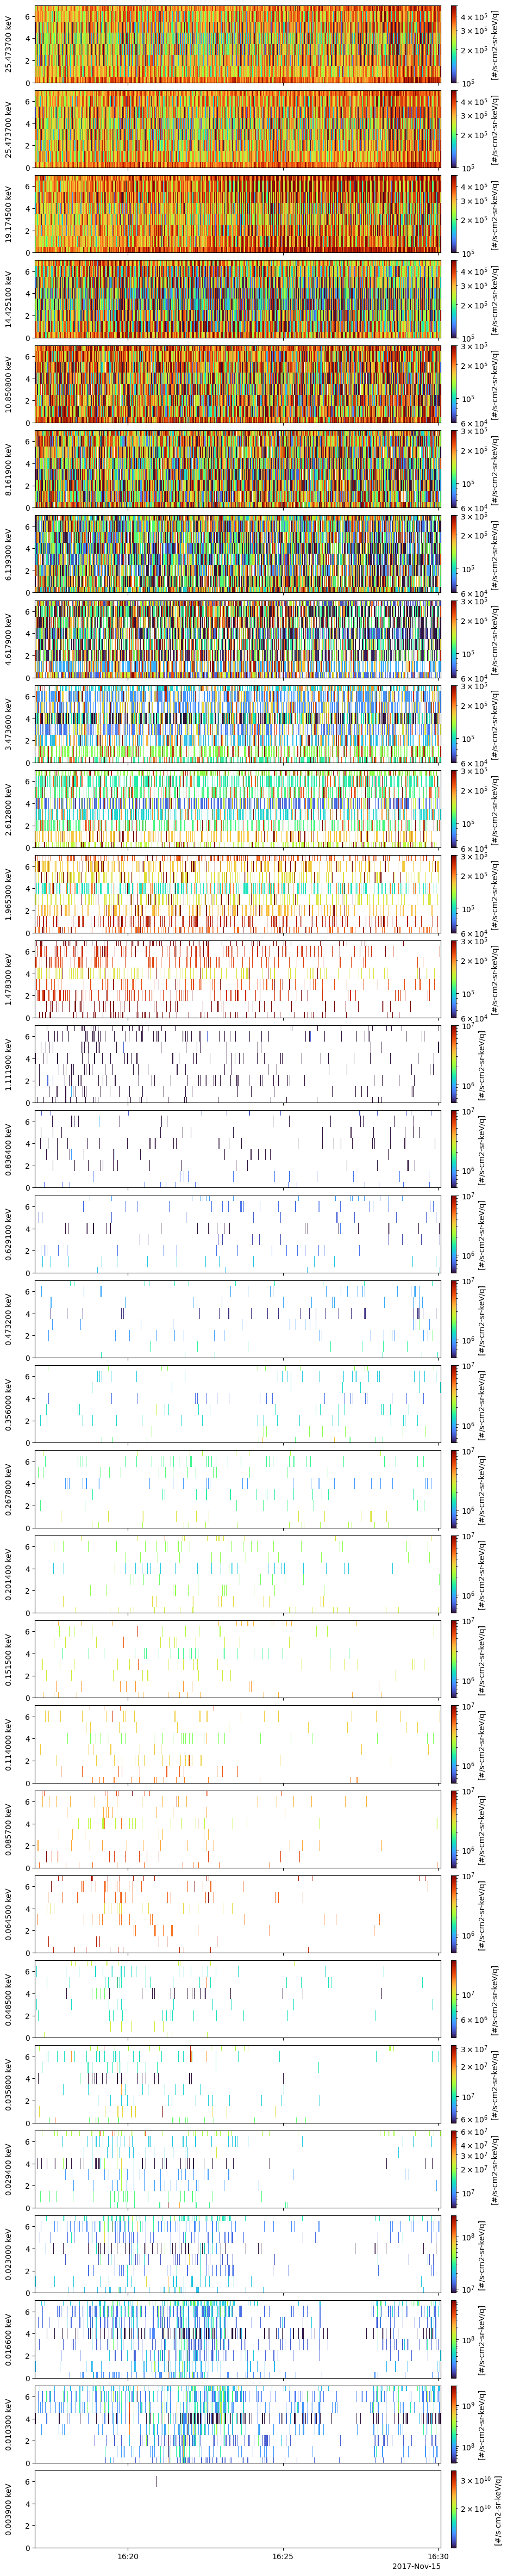

In [45]:
import stpp_tplot

for energy_i in range(energy_num):
    stpp_tplot.store_data(f'erg_lepi_l2_3dflux_FPDU_energy_{energy_i}', data={'x': flux_data_arrays[energy_i].time, 'y': flux_data_arrays[energy_i].values, 'v': flux_data_arrays[energy_i].channel})
    if energy_i >= 0 and energy_i <= 3:
        stpp_tplot.op(f'erg_lepi_l2_3dflux_FPDU_energy_{energy_i}', spec=1, zlog=1, z_range=[1E5, 5E5], y_range=[0, 7], z_label= '[#/s-cm2-sr-keV/q]', y_label=f'{float(flux_data_arrays[energy_i].energy_keV):2f} keV')
    elif energy_i >= 4 and energy_i <= 11:
        stpp_tplot.op(f'erg_lepi_l2_3dflux_FPDU_energy_{energy_i}', spec=1, zlog=1, z_range=[6E4, 3E5], y_range=[0, 7], z_label= '[#/s-cm2-sr-keV/q]', y_label=f'{float(flux_data_arrays[energy_i].energy_keV):2f} keV')
    elif energy_i >= 12 and energy_i <= 22:
        stpp_tplot.op(f'erg_lepi_l2_3dflux_FPDU_energy_{energy_i}', spec=1, zlog=1, z_range=[5E5, 1E7], y_range=[0, 7], z_label= '[#/s-cm2-sr-keV/q]', y_label=f'{float(flux_data_arrays[energy_i].energy_keV):2f} keV')
    else:
        stpp_tplot.op(f'erg_lepi_l2_3dflux_FPDU_energy_{energy_i}', spec=1, zlog=1, y_range=[0, 7], z_label= '[#/s-cm2-sr-keV/q]', y_label=f'{float(flux_data_arrays[energy_i].energy_keV):2f} keV')

stpp_tplot.mp([f'erg_lepi_l2_3dflux_FPDU_energy_{energy_i}' for energy_i in range(energy_num)])